In [1]:
import matplotlib.pyplot as plt
import torch
from nnfabrik.builder import get_data, get_trainer

from sensorium2020_adapted import stacked_core_full_gauss_readout
from wandb_trainer import standard_trainer

random_seed = 42

device = "cuda:7"
torch.cuda.set_device(device)

In [2]:
# loading the SENSORIUM+ dataset
filenames = [
    "/srv/user/polina/sensorium/sensorium/notebooks/data/static23343-5-17-GrayImageNet-94c6ff995dac583098847cfecd43e7b6.zip",
]

dataset_fn = "sensorium.datasets.static_loaders"
dataset_config = {
    "paths": filenames,
    "normalize": True,
    "exclude": 'images',
    "include_behavior": False,
    "include_eye_position": True,
    "batch_size": 128,
    "scale": 0.25,
}

dataloaders = get_data(dataset_fn, dataset_config)

In [3]:
#next(iter(dataloaders['train']['23343-5-17']))[0]

In [4]:
model_config = {
    "pad_input": False,
    "stack": -1,
    "layers": 4,
    "input_kern": 9,
    "gamma_input": 6.3831,
    "gamma_readout": 0.0076,
    "hidden_kern": 7,
    "hidden_channels": 64,
    "depth_separable": True,
    "grid_mean_predictor": {
        "type": "cortex",
        "input_dimensions": 2,
        "hidden_layers": 1,
        "hidden_features": 30,
        "final_tanh": True,
    },
    "init_sigma": 0.1,
    "init_mu_range": 0.3,
    "gauss_type": "full",
}

model_config["shifter"] = False
model_config["perspective"] = True

In [5]:
model = stacked_core_full_gauss_readout(dataloaders, random_seed, **model_config)

/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/neuralpredictors/layers/readouts/base.py:74: UserWarning: Use of 'gamma_readout' is deprecated. Use 'feature_reg_weight' instead. If 'feature_reg_weight' is defined, 'gamma_readout' is ignored
  warnings.warn(
/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")


In [6]:
trainer_fn = "sensorium.training.standard_trainer"

trainer_config = {
    "max_iter": 200,
    "verbose": False,
    "lr_decay_steps": 4,
    "avg_loss": False,
    "lr_init": 0.009,
    "track_training": False,
}

trainer_config["device"] = "cuda:7"

#trainer = get_trainer(trainer_fn=trainer_fn, trainer_config=trainer_config)

In [7]:
#validation_score, trainer_output, state_dict = trainer(
#    model, dataloaders, seed=random_seed
#)

validation_score, trainer_output, state_dict = standard_trainer(
    model, 
    dataloaders, 
    random_seed, 
    max_iter=200, 
    verbose=False, 
    lr_decay_steps=4, 
    avg_loss=False, 
    lr_init=0.009, 
    track_training=False, 
    device=device,
    wandb_project='perspective'
)

/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


wandb: Currently logged in as: nathan-soeding (nathan-soeding-uni-goettingen) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/neuralpredictors/layers/readouts/gaussian.py:582: UserWarning: the specified feature map dimension is not the readout's expected input dimension
  warnings.warn("the specified feature map dimension is not the readout's expected input dimension")
Epoch 86: 100%|██████████| 35/35 [00:03<00:00,  9.65it/s]


final/validation_corr_all,▁
final/validation_corr_mean,▁
val/correlation,▁▂▄▅▅▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇████████████████████
val/poisson_loss,█▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
final/validation_corr_all,0.35366
final/validation_corr_mean,0.35366
val/correlation,0.35329
val/poisson_loss,2186373.0


In [13]:
validation_score

np.float32(0.3536585)

In [9]:
list(model.perspective.parameters())

[Parameter containing:
 tensor([-0.3265, -0.1518, -0.1572, -0.0487, -0.0011, -0.2239, -0.1025, -0.1356,
         -0.6027, -0.0720,  0.0063, -0.0244, -0.2617, -0.1337, -0.1322,  0.0569],
        device='cuda:7', requires_grad=True),
 Parameter containing:
 tensor([[0.8524],
         [0.9734],
         [0.9366],
         [0.4884],
         [0.1795],
         [0.5894],
         [0.4513],
         [0.5981],
         [0.8828],
         [0.5186],
         [0.7010],
         [0.3305],
         [0.5442],
         [0.2165],
         [0.5007],
         [0.9933]], device='cuda:7', requires_grad=True),
 Parameter containing:
 tensor([[ 1.2578, -0.0435],
         [ 0.1963,  1.0542],
         [ 1.2074,  0.2900],
         [ 0.1870, -1.0377],
         [-0.5758, -0.0858],
         [ 0.0501, -1.0510],
         [-0.6282,  0.2130],
         [ 0.9002,  0.1162],
         [ 0.5087, -0.7403],
         [ 0.0839, -0.9763],
         [-1.3008, -0.0831],
         [-0.5944, -0.2447],
         [ 0.0874,  1.0257],
  

img shape: torch.Size([128, 36, 64])
perspective output shape: torch.Size([128, 36, 54])


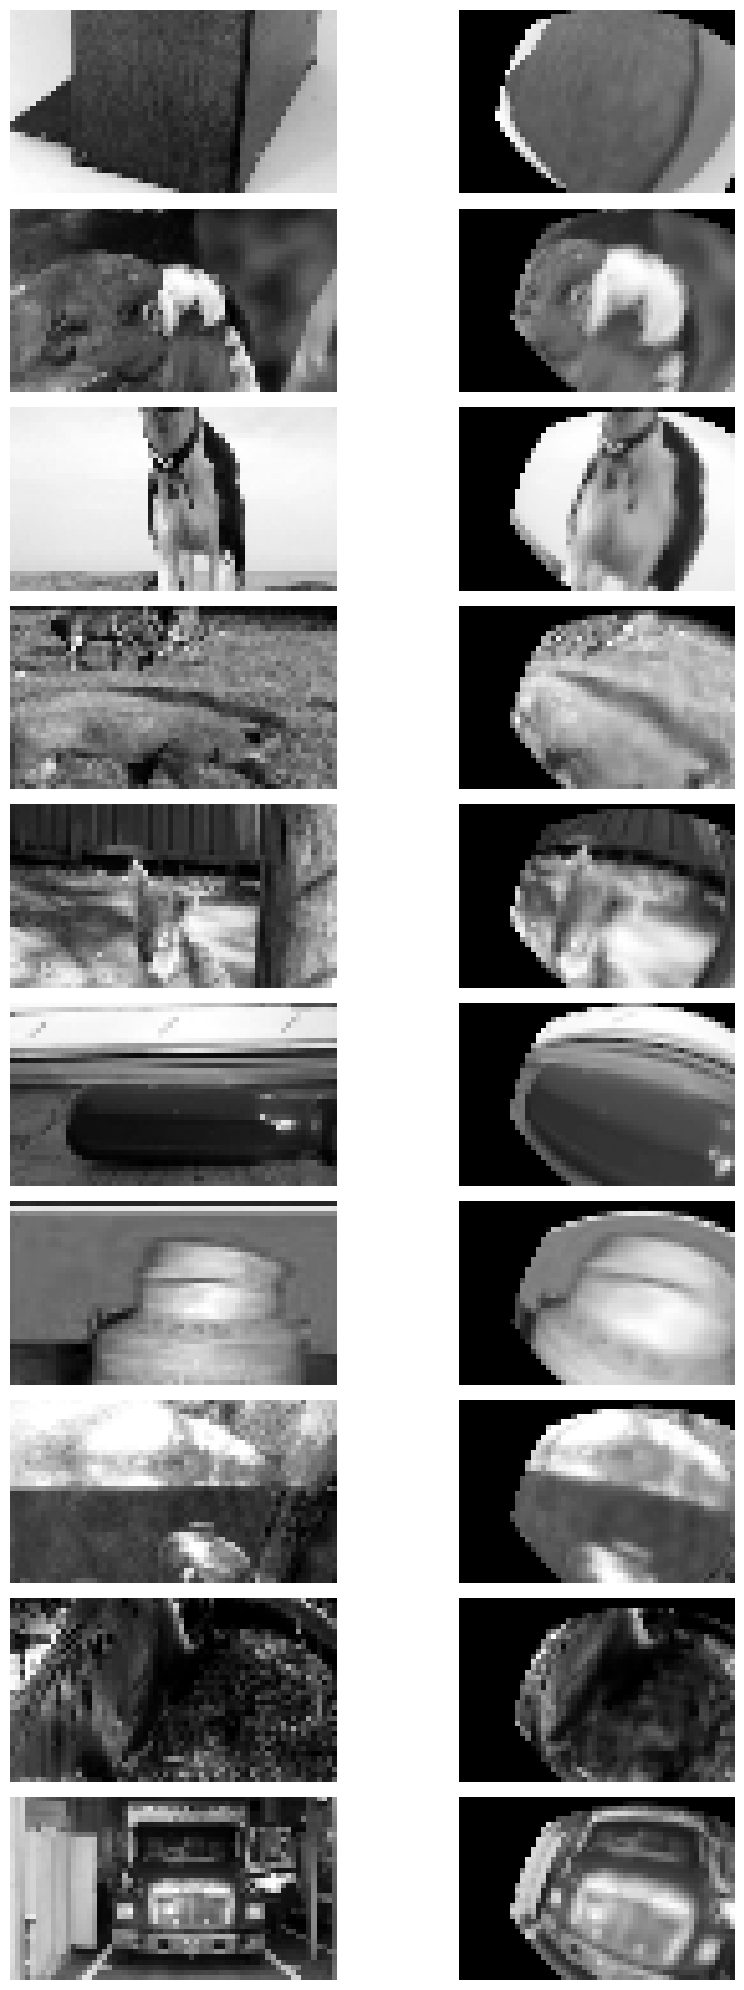

In [10]:
model.to(device)
data_key = "23343-5-17"
batch = next(iter(dataloaders["train"][data_key]))

fig, ax = plt.subplots(10, 2, figsize=(10, 20))

imgs = batch.images[:, 0].detach().cpu()
out = model.perspective[data_key](batch.images, batch.pupil_center)[:, 0].detach().cpu()
print("img shape:", imgs.shape)
print("perspective output shape:", out.shape)

for i in range(10):
    ax[i, 0].imshow(imgs[i], cmap="gray")
    ax[i, 0].axis("off")
    ax[i, 1].imshow(out[i], cmap="gray")
    ax[i, 1].axis("off")

plt.tight_layout()
plt.show()

In [11]:
model.perspective[data_key].retina.mlp

Sequential(
  (0): ParametrizedLinear(
    in_features=2, out_features=16, bias=True
    (parametrizations): ModuleDict(
      (weight): ParametrizationList(
        (0): _WeightNorm()
      )
    )
  )
  (1): GELU(approximate='none')
  (2): ParametrizedLinear(
    in_features=16, out_features=16, bias=True
    (parametrizations): ModuleDict(
      (weight): ParametrizationList(
        (0): _WeightNorm()
      )
    )
  )
  (3): GELU(approximate='none')
  (4): ParametrizedLinear(
    in_features=16, out_features=16, bias=True
    (parametrizations): ModuleDict(
      (weight): ParametrizationList(
        (0): _WeightNorm()
      )
    )
  )
  (5): GELU(approximate='none')
  (6): ParametrizedLinear(
    in_features=16, out_features=2, bias=True
    (parametrizations): ModuleDict(
      (weight): ParametrizationList(
        (0): _WeightNorm()
      )
    )
  )
)

In [12]:
model.perspective[data_key].retina.mlp(batch.pupil_center)

tensor([[-0.0449, -0.0351],
        [-0.0186, -0.1881],
        [ 0.0071, -0.1796],
        [ 0.0541, -0.1795],
        [ 0.0326, -0.1741],
        [ 0.0082, -0.1708],
        [ 0.0754, -0.1994],
        [ 0.0723, -0.1900],
        [ 0.0880, -0.2140],
        [ 0.0662, -0.1856],
        [ 0.0810, -0.2029],
        [-0.0037, -0.1575],
        [ 0.0319, -0.1757],
        [ 0.0669, -0.1912],
        [-0.0430, -0.0297],
        [ 0.0539, -0.1993],
        [ 0.0545, -0.1866],
        [-0.0573, -0.1436],
        [ 0.0734, -0.1937],
        [-0.0344, -0.1585],
        [ 0.0490, -0.1771],
        [-0.0386, -0.0333],
        [-0.0159, -0.2272],
        [-0.0011, -0.1727],
        [ 0.0142, -0.1674],
        [ 0.0856, -0.2085],
        [ 0.0795, -0.2025],
        [ 0.0508, -0.1984],
        [-0.0075, -0.2458],
        [ 0.0472, -0.1770],
        [ 0.0157, -0.1797],
        [-0.0597, -0.0842],
        [-0.0225, -0.0958],
        [ 0.0653, -0.1955],
        [-0.0420, -0.0388],
        [ 0.0845, -0